In [7]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [8]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,target_ax,target_yaw,static
0,0.0,9.816496,-0.971,-3.01151,56.9,0.00050,2.223,-0.684,0.54692,-0.072785,0.583564,11.628,False
1,0.1,9.770532,-0.901,-3.95340,57.0,0.45201,2.604,-0.468,0.72402,-0.107422,0.585722,11.625,False
2,0.2,9.784359,-0.824,-4.00435,56.9,-0.47514,3.016,-0.252,0.61244,-0.095164,0.561323,11.625,False
3,0.3,9.767002,-0.740,-4.19792,57.0,0.11488,3.447,0.036,0.63662,-0.081886,0.545456,11.633,False
4,0.4,9.806758,-0.656,-4.20634,56.9,-0.07570,3.871,0.432,0.71959,-0.108422,0.592724,11.639,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.774190,-0.638,-0.16637,57.4,-0.17294,3.337,0.468,-0.09776,-0.144550,0.576298,13.335,True
1297,129.6,9.744397,-0.634,-0.58104,57.4,0.22483,3.339,0.468,-0.06197,-0.093879,0.572355,13.338,True
1298,129.7,9.749781,-0.635,0.03523,57.3,0.03419,3.341,0.468,0.12510,-0.134322,0.562608,13.338,True
1299,129.8,9.735395,-0.634,0.23015,57.4,-0.15196,3.341,0.468,0.07650,-0.094516,0.592214,13.339,True


In [9]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_ay,ref_sample_time,ref_q1,ref_roll,ref_wz,ref_la_pos_mon_d,ref_wy,ref_q3,ref_pitch,ref_q2,ref_wx,ref_az,ref_ax,ref_q0,ref_yaw,static
0,0.0,9.770,605000000.0,-0.20360,-88.92305,3.089388,-1.404,-0.055961,0.6888,1.738354,-0.6702,0.042531,-0.1864,0.1592,0.186700,147.994998,False
1,0.1,9.777,705000000.0,-0.20560,-88.92305,3.720788,-1.404,-0.097346,0.6894,2.093015,-0.6696,0.043699,-0.1864,0.1522,0.184500,147.994998,False
2,0.2,9.785,805000000.0,-0.20790,-88.92305,4.145350,-1.404,-0.161345,0.6901,2.496377,-0.6689,0.009305,-0.1857,0.1448,0.182000,147.994998,False
3,0.3,9.791,905000000.0,-0.21030,-88.92305,4.332707,-1.404,-0.140375,0.6908,2.924950,-0.6681,0.008417,-0.1853,0.1363,0.179300,148.052294,False
4,0.4,9.795,5000000.0,-0.21280,-88.92305,4.283432,-1.404,-0.107773,0.6915,3.355814,-0.6673,-0.011471,-0.1852,0.1268,0.176600,148.052294,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.786,105000000.0,-0.03197,-88.92305,0.020506,2.007,-0.158423,0.7136,1.953786,-0.6998,0.002401,-0.1856,0.1385,0.008241,176.757480,True
1297,129.6,9.782,205000000.0,-0.03188,-88.92305,0.015539,2.005,-0.162777,0.7136,1.954932,-0.6998,-0.013694,-0.1846,0.1384,0.008133,176.757480,True
1298,129.7,9.784,305000000.0,-0.03179,-88.92305,0.009368,2.004,-0.158079,0.7136,1.955505,-0.6998,-0.002935,-0.1850,0.1378,0.008034,176.814776,True
1299,129.8,9.784,405000000.0,-0.03170,-88.92305,0.009706,2.002,-0.172174,0.7136,1.956651,-0.6998,0.004946,-0.1851,0.1378,0.007925,176.814776,True


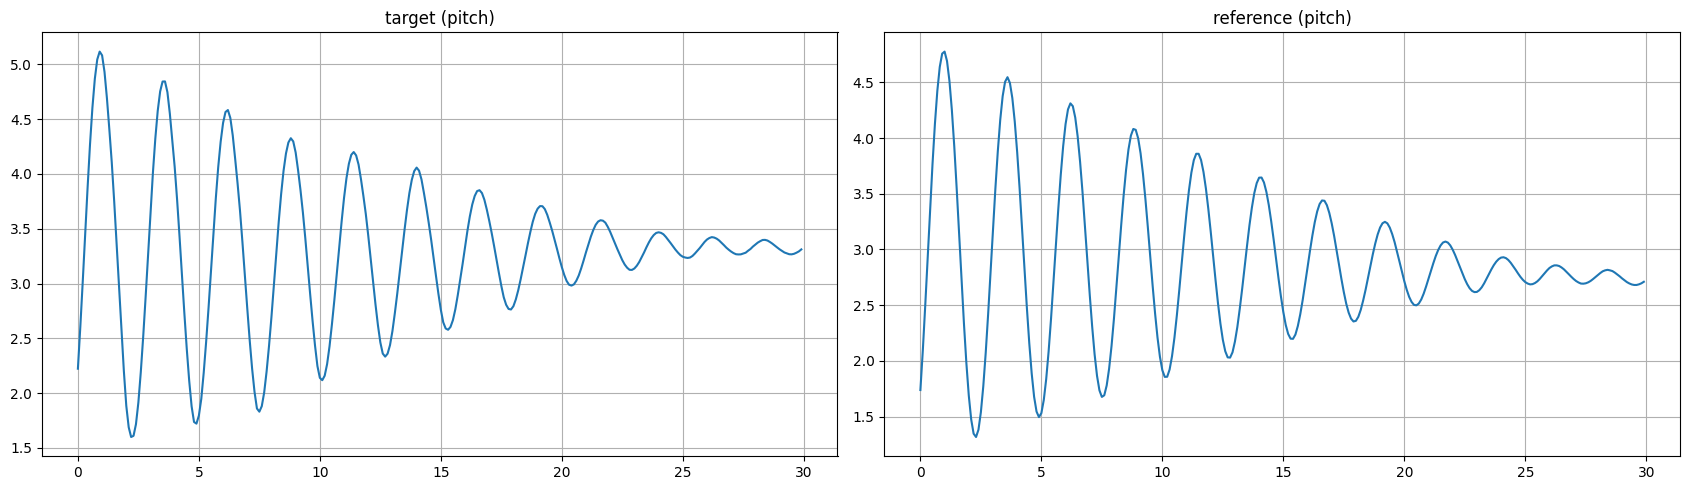

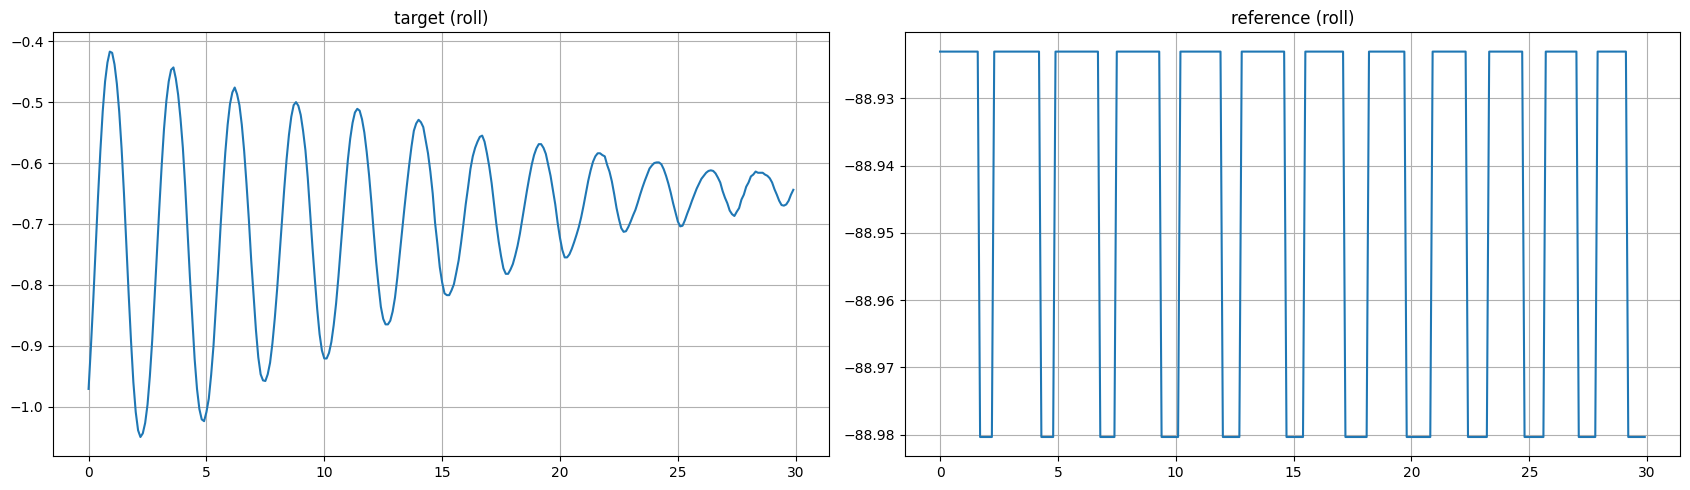

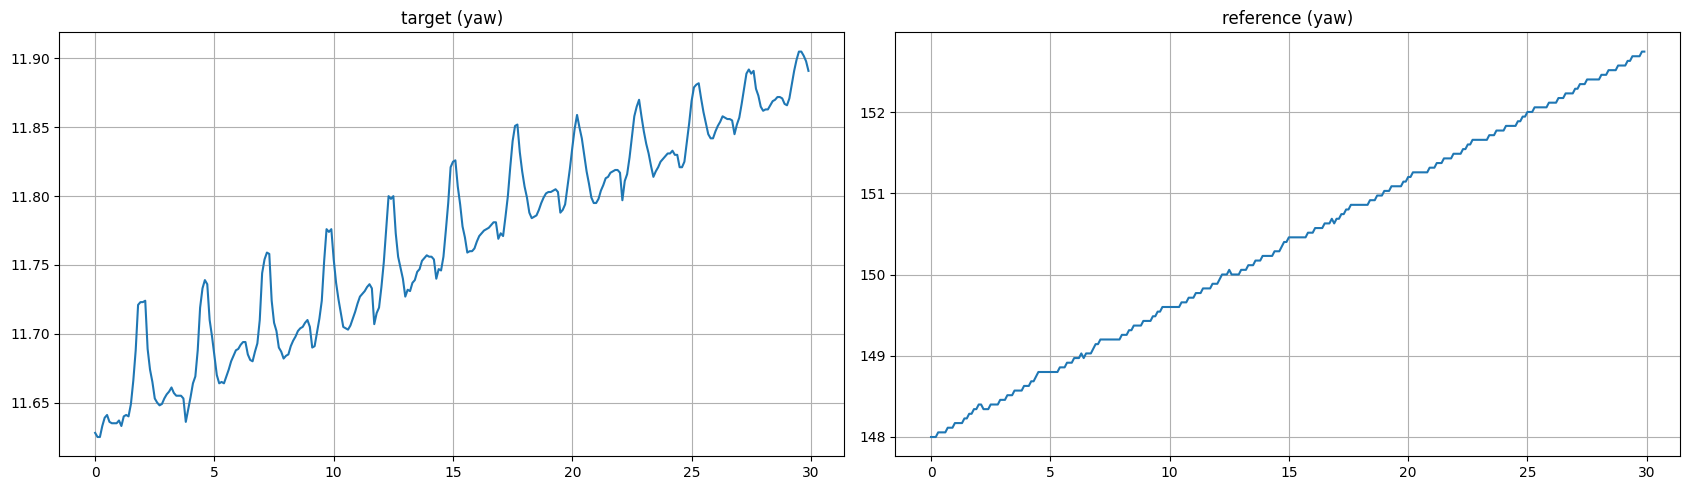

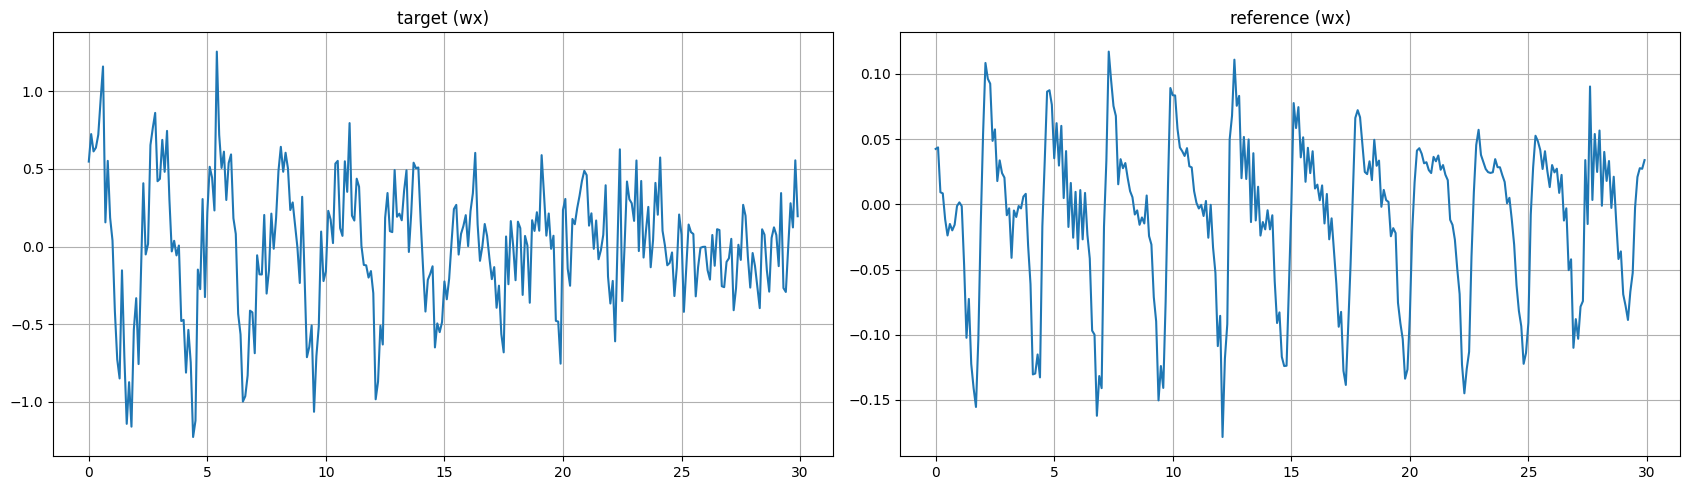

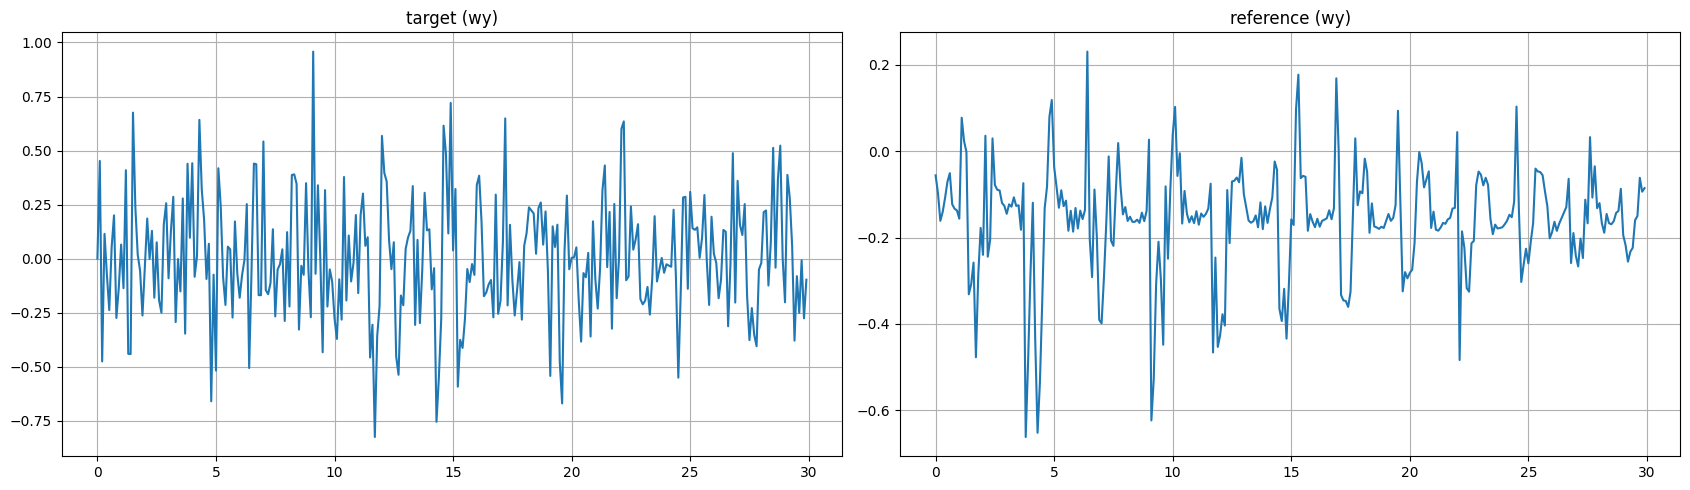

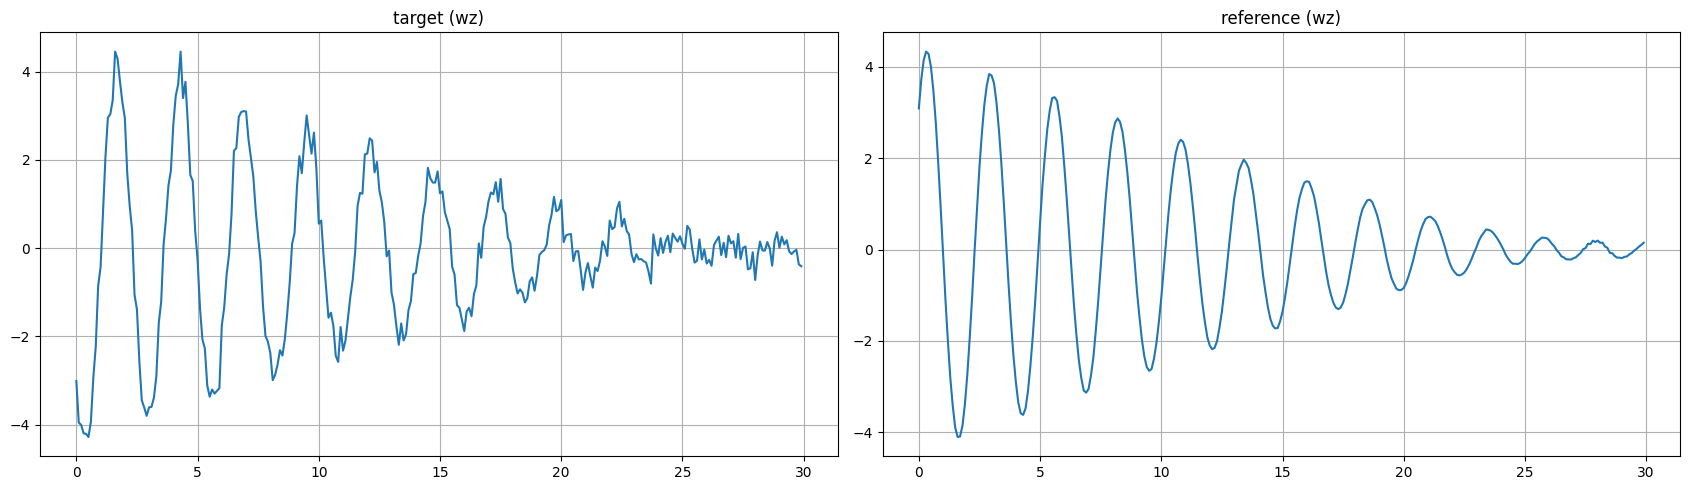

In [10]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target.loc[~df_target.static][f'target_{var}'], 
        f'reference ({var})': df_ref.loc[~df_ref.static][f'ref_{var}']
    }, time=df_ref.loc[~df_ref.static].time, figsize=(17, 5))

In [11]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_ay,target_roll,target_wz,target_tmp,target_wy,target_pitch,target_e,target_wx,target_az,target_ax,target_yaw,static,ref_ay,ref_sample_time,ref_q1,ref_roll,ref_wz,ref_la_pos_mon_d,ref_wy,ref_q3,ref_pitch,ref_q2,ref_wx,ref_az,ref_ax,ref_q0,ref_yaw
0,0.0,9.816496,-0.971,-3.01151,56.9,0.00050,2.223,-0.684,0.54692,-0.072785,0.583564,11.628,False,9.770,605000000.0,-0.20360,-88.92305,3.089388,-1.404,-0.055961,0.6888,1.738354,-0.6702,0.042531,-0.1864,0.1592,0.186700,147.994998
1,0.1,9.770532,-0.901,-3.95340,57.0,0.45201,2.604,-0.468,0.72402,-0.107422,0.585722,11.625,False,9.777,705000000.0,-0.20560,-88.92305,3.720788,-1.404,-0.097346,0.6894,2.093015,-0.6696,0.043699,-0.1864,0.1522,0.184500,147.994998
2,0.2,9.784359,-0.824,-4.00435,56.9,-0.47514,3.016,-0.252,0.61244,-0.095164,0.561323,11.625,False,9.785,805000000.0,-0.20790,-88.92305,4.145350,-1.404,-0.161345,0.6901,2.496377,-0.6689,0.009305,-0.1857,0.1448,0.182000,147.994998
3,0.3,9.767002,-0.740,-4.19792,57.0,0.11488,3.447,0.036,0.63662,-0.081886,0.545456,11.633,False,9.791,905000000.0,-0.21030,-88.92305,4.332707,-1.404,-0.140375,0.6908,2.924950,-0.6681,0.008417,-0.1853,0.1363,0.179300,148.052294
4,0.4,9.806758,-0.656,-4.20634,56.9,-0.07570,3.871,0.432,0.71959,-0.108422,0.592724,11.639,False,9.795,5000000.0,-0.21280,-88.92305,4.283432,-1.404,-0.107773,0.6915,3.355814,-0.6673,-0.011471,-0.1852,0.1268,0.176600,148.052294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,129.5,9.774190,-0.638,-0.16637,57.4,-0.17294,3.337,0.468,-0.09776,-0.144550,0.576298,13.335,True,9.786,105000000.0,-0.03197,-88.92305,0.020506,2.007,-0.158423,0.7136,1.953786,-0.6998,0.002401,-0.1856,0.1385,0.008241,176.757480
1297,129.6,9.744397,-0.634,-0.58104,57.4,0.22483,3.339,0.468,-0.06197,-0.093879,0.572355,13.338,True,9.782,205000000.0,-0.03188,-88.92305,0.015539,2.005,-0.162777,0.7136,1.954932,-0.6998,-0.013694,-0.1846,0.1384,0.008133,176.757480
1298,129.7,9.749781,-0.635,0.03523,57.3,0.03419,3.341,0.468,0.12510,-0.134322,0.562608,13.338,True,9.784,305000000.0,-0.03179,-88.92305,0.009368,2.004,-0.158079,0.7136,1.955505,-0.6998,-0.002935,-0.1850,0.1378,0.008034,176.814776
1299,129.8,9.735395,-0.634,0.23015,57.4,-0.15196,3.341,0.468,0.07650,-0.094516,0.592214,13.339,True,9.784,405000000.0,-0.03170,-88.92305,0.009706,2.002,-0.172174,0.7136,1.956651,-0.6998,0.004946,-0.1851,0.1378,0.007925,176.814776


In [12]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)